In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

In [3]:
df=pd.read_csv("../data/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
print("Shape:",df.shape)
#print("info:",df.info)
print("Null values:",df.isnull().sum())

Shape: (768, 9)
Null values: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
X=df.iloc[:,:-2]
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction
0,6,148,72,35,0,33.6,0.627
1,1,85,66,29,0,26.6,0.351
2,8,183,64,0,0,23.3,0.672
3,1,89,66,23,94,28.1,0.167
4,0,137,40,35,168,43.1,2.288
...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171
764,2,122,70,27,0,36.8,0.340
765,5,121,72,23,112,26.2,0.245
766,1,126,60,0,0,30.1,0.349


In [8]:
y=df.iloc[:,-1:]
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [12]:
X_train

array([[-0.52639686, -1.15139792, -3.75268255, ..., -0.70120553,
        -4.13525578, -0.49073479],
       [ 1.58804586, -0.27664283,  0.68034485, ..., -0.70120553,
        -0.48916881,  2.41502991],
       [-0.82846011,  0.56687102, -1.2658623 , ...,  0.01344832,
        -0.42452187,  0.54916055],
       ...,
       [ 1.8901091 , -0.62029661,  0.89659009, ..., -0.70120553,
         1.76054443,  1.981245  ],
       [-1.13052335,  0.62935353, -3.75268255, ..., -0.70120553,
         1.34680407, -0.78487662],
       [-1.13052335,  0.12949347,  1.43720319, ..., -0.70120553,
        -1.22614383, -0.61552223]], shape=(614, 7))

In [13]:
from sklearn.tree import DecisionTreeClassifier
clsfr_entropy=DecisionTreeClassifier(criterion='entropy',random_state=2)
clsfr_entropy.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",2
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
y_pred=clsfr_entropy.predict(X_test)

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[78, 21],
       [17, 38]])

In [17]:
accuracy=(cm[0][0]+cm[1][1])/(cm[0][0]+cm[0][1]+cm[1][0]+cm[1][1])
accuracy

np.float64(0.7532467532467533)

In [19]:
from sklearn.metrics import accuracy_score
accuracy_percentage_20 = accuracy * 100
print(f"Accuracy: {accuracy_percentage_20}%")

Accuracy: 75.32467532467533%


[Text(0.48718398876404495, 0.975, 'x[1] <= 0.208\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.1836376404494382, 0.925, 'x[5] <= -0.715\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.3354108146067416, 0.95, 'True  '),
 Text(0.0449438202247191, 0.875, 'x[2] <= 1.329\nentropy = 0.132\nsamples = 109\nvalue = [107, 2]'),
 Text(0.02247191011235955, 0.825, 'x[6] <= 0.613\nentropy = 0.078\nsamples = 105\nvalue = [104, 1]'),
 Text(0.011235955056179775, 0.775, 'entropy = 0.0\nsamples = 91\nvalue = [91, 0]'),
 Text(0.033707865168539325, 0.775, 'x[6] <= 0.702\nentropy = 0.371\nsamples = 14\nvalue = [13, 1]'),
 Text(0.02247191011235955, 0.725, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.0449438202247191, 0.725, 'entropy = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.06741573033707865, 0.825, 'x[5] <= -2.687\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.056179775280898875, 0.775, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.0786516853

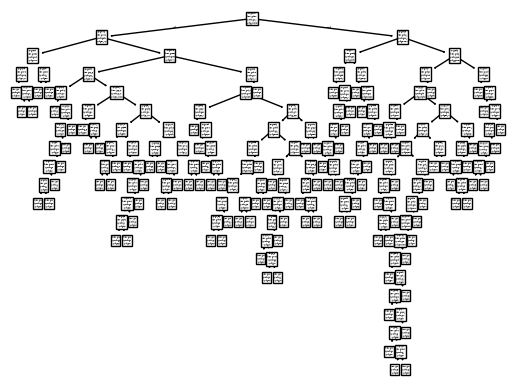

In [20]:
from sklearn import tree
tree.plot_tree(clsfr_entropy)

In [21]:
clsfr_gini=DecisionTreeClassifier(criterion='gini', random_state=42)
clsfr_gini.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [22]:
y_pred_gini=clsfr_gini.predict(X_test)
y_pred_gini

array([1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0])

In [23]:
cm_gini=confusion_matrix(y_test,y_pred_gini)
cm_gini

array([[63, 36],
       [18, 37]])

In [24]:
accuracy_gini=(cm_gini[0][0]+cm_gini[1][1])/(cm_gini[0][0]+cm_gini[0][1]+cm_gini[1][0]+cm_gini[1][1])
accuracy_gini

np.float64(0.6493506493506493)

In [27]:
accuracy_percentage_gini_20 = accuracy_gini * 100
print(f"Accuracy: {accuracy_percentage_gini_20}%")

Accuracy: 64.93506493506493%


In [28]:
print(f"Accuracy for entropy: {accuracy_percentage_20}%")
print(f"Accuracy for gini: {accuracy_percentage_gini_20}%")

Accuracy for entropy: 75.32467532467533%
Accuracy for gini: 64.93506493506493%


In [35]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X,y,test_size=0.25,random_state=42)

scaler=StandardScaler()
X_train1=scaler.fit_transform(X_train1)
X_test1=scaler.fit_transform(X_test1)

clsfr_entropy1=DecisionTreeClassifier(criterion='entropy', random_state=11)
clsfr_entropy1.fit(X_train1,y_train1)

y_pred1=clsfr_entropy.predict(X_test1)

from sklearn.metrics import confusion_matrix
cm1=confusion_matrix(y_test1,y_pred1)
print(cm1)

accuracy1=(cm1[0][0]+cm1[1][1])/(cm1[0][0]+cm1[0][1]+cm1[1][0]+cm1[1][1])
accuracy1

accuracy_percentage_25 = accuracy1 * 100

clsfr_gini1=DecisionTreeClassifier(criterion='gini', random_state=42)
clsfr_gini1.fit(X_train1,y_train1)

y_pred_gini1=clsfr_gini1.predict(X_test1)

cm_gini1=confusion_matrix(y_test1,y_pred_gini1)
print(cm_gini1)

accuracy_gini1=(cm_gini1[0][0]+cm_gini1[1][1])/(cm_gini1[0][0]+cm_gini1[0][1]+cm_gini1[1][0]+cm_gini1[1][1])
accuracy_gini1

accuracy_percentage_gini1_25 = accuracy_gini1 * 100

print(f"Accuracy for entropy: {accuracy_percentage_25}%")
print(f"Accuracy for gini: {accuracy_percentage_gini1_25}%")

[[96 27]
 [19 50]]
[[91 32]
 [31 38]]
Accuracy for entropy: 76.04166666666666%
Accuracy for gini: 67.1875%


In [36]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X,y,test_size=0.30,random_state=42)

scaler=StandardScaler()
X_train2=scaler.fit_transform(X_train2)
X_test2=scaler.fit_transform(X_test2)

clsfr_entropy2=DecisionTreeClassifier(criterion='entropy', random_state=11)
clsfr_entropy2.fit(X_train2,y_train2)

y_pred2=clsfr_entropy.predict(X_test2)

from sklearn.metrics import confusion_matrix
cm2=confusion_matrix(y_test2,y_pred2)
print(cm2)

accuracy2=(cm2[0][0]+cm2[1][1])/(cm2[0][0]+cm2[0][1]+cm2[1][0]+cm2[1][1])
accuracy2

accuracy_percentage_30 = accuracy2 * 100

clsfr_gini2=DecisionTreeClassifier(criterion='gini', random_state=42)
clsfr_gini2.fit(X_train2,y_train2)

y_pred_gini2=clsfr_gini2.predict(X_test2)

cm_gini2=confusion_matrix(y_test2,y_pred_gini2)
print(cm_gini2)

accuracy_gini2=(cm_gini2[0][0]+cm_gini2[1][1])/(cm_gini2[0][0]+cm_gini2[0][1]+cm_gini2[1][0]+cm_gini2[1][1])
accuracy_gini2

accuracy_percentage_gini1_30 = accuracy_gini2 * 100

print(f"Accuracy for entropy: {accuracy_percentage_30}%")
print(f"Accuracy for gini: {accuracy_percentage_gini1_30}%")

[[121  30]
 [ 19  61]]
[[114  37]
 [ 32  48]]
Accuracy for entropy: 78.78787878787878%
Accuracy for gini: 70.12987012987013%


In [38]:
print("accuracy for diabetes dataset\n")
data = {
    "Split Ratio": [0.20, 0.25, 0.30],
    "Entropy Accuracy (%)": [accuracy_percentage_20, accuracy_percentage_25, accuracy_percentage_30],
    "Gini Accuracy (%)": [accuracy_percentage_gini_20, accuracy_percentage_gini1_25, accuracy_percentage_gini1_30] 
}

# 2. Create and display the DataFrame
df = pd.DataFrame(data)
print(df.to_string(index=False))

accuracy for diabetes dataset

 Split Ratio  Entropy Accuracy (%)  Gini Accuracy (%)
        0.20             75.324675          64.935065
        0.25             76.041667          67.187500
        0.30             78.787879          70.129870
